# VaR backtesting

Compare four 99% VaR models on SPY daily returns:

- **HS**: historical simulation over a 500-day window
- **EWMA normal**: EWMA volatility (λ = 0.94) with a normal quantile
- **EWMA t**: EWMA volatility with a unit-variance Student-t quantile (ν = 5)
- **GARCH t**: GARCH(1,1) volatility, refitted every 21 days on the trailing 1,000 days, with the same Student-t quantile (ν = 5)

For each model we count the breaches (days the loss was bigger than the VaR forecast) and run three tests:

- **Kupiec**: is the breach rate consistent with `alpha`?
- **Christoffersen**: are breaches independent, or does a breach make another one tomorrow more likely?
- **Conditional coverage**: both at once (the two LR statistics added, χ² with 2 degrees of freedom)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# make src/ importable whether the notebook runs from the repo root or notebooks/
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(root / "src"))

from backtesting import christoffersen, conditional_coverage, exceedance, kupiec, summary
from data import clean_prices, download_prices, to_returns
from model import ewma_vol, garch_vol, hs_var, param_var

## Data

In [2]:
prices = clean_prices(download_prices(["SPY"]))
returns = to_returns(prices)["SPY"]
returns.describe()

[*********************100%***********************]  1 of 1 completed

Index(['SPY'], dtype='str', name='Ticker')
dropped: 0 rows with all missing values


count    4215.000000
mean        0.000585
std         0.010735
min        -0.109424
25%        -0.003708
50%         0.000699
75%         0.005791
max         0.105019
Name: SPY, dtype: float64

## VaR forecasts

Every model already shifts its estimate by one day, so `var[t]` only uses returns up to `t - 1`. The backtest compares it directly with `returns[t]`, with no extra shift.

HS needs 450 days of history before it produces a number, EWMA needs only 30, and GARCH needs 1,000 to estimate its parameters. To compare like with like, all four models are cut to the dates where every one of them has a forecast.

In [3]:
ALPHA = 0.01

sigma = ewma_vol(returns)
sigma_garch = garch_vol(returns)
var = pd.DataFrame(
    {
        "HS": hs_var(returns, alpha=ALPHA),
        "EWMA normal": param_var(sigma, alpha=ALPHA, dist="normal"),
        "EWMA t": param_var(sigma, alpha=ALPHA, dist="t", nu=5),
        "GARCH t": param_var(sigma_garch, alpha=ALPHA, dist="t", nu=5),
    }
).dropna()
returns_bt = returns.loc[var.index]

print(f"backtest window: {var.index[0]:%Y-%m-%d} to {var.index[-1]:%Y-%m-%d}, {len(var)} days")

backtest window: 2013-12-24 to 2026-10-07, 3215 days


## Breaches and coverage tests

A p-value below 0.05 rejects the model. Kupiec fails models in both directions, so too few breaches (an overly conservative VaR) is a failure too. Christoffersen only looks at whether breaches depend on the previous day, so a model can pass it with far too many breaches, as long as they're spread out.

In [4]:
hits = {name: exceedance(returns_bt, var[name]) for name in var.columns}

TESTS = {
    "kupiec": lambda h: kupiec(h, ALPHA),
    "christoffersen": lambda h: christoffersen(h, ALPHA),
    "cond_coverage": lambda h: conditional_coverage(h, ALPHA),
}

rows = []
for name, h in hits.items():
    row = {"model": name, **summary(h, ALPHA)}
    for test, func in TESTS.items():
        row[f"{test}_p"] = func(h)[1]
    rows.append(row)

results = pd.DataFrame(rows).set_index("model")
verdicts = (results[[f"{t}_p" for t in TESTS]] < 0.05).replace({True: "reject", False: "pass"})
verdicts.columns = list(TESTS)

display(results.round({"expected": 1, "hit_rate": 4}).round(4))
verdicts

,n,exceedances,expected,hit_rate,kupiec_p,christoffersen_p,cond_coverage_p
model,,,,,,,
HS,3215,49,32.2,0.0152,0.0056,0.0000,0.0000
EWMA normal,3215,75,32.2,0.0233,0.0000,0.0091,0.0000
EWMA t,3215,58,32.2,0.0180,0.0000,0.0040,0.0000
GARCH t,3215,46,32.2,0.0143,0.0211,0.0041,0.0011


,kupiec,christoffersen,cond_coverage
model,,,
HS,reject,reject,reject
EWMA normal,reject,reject,reject
EWMA t,reject,reject,reject
GARCH t,reject,reject,reject


## Returns against VaR

Each panel shows the daily return in grey, the negative VaR forecast as a line, and breaches as dots. Look at how fast each model's line reacts to the March 2020 crash: HS barely moves, so its breaches pile up in a few weeks. EWMA widens within days.

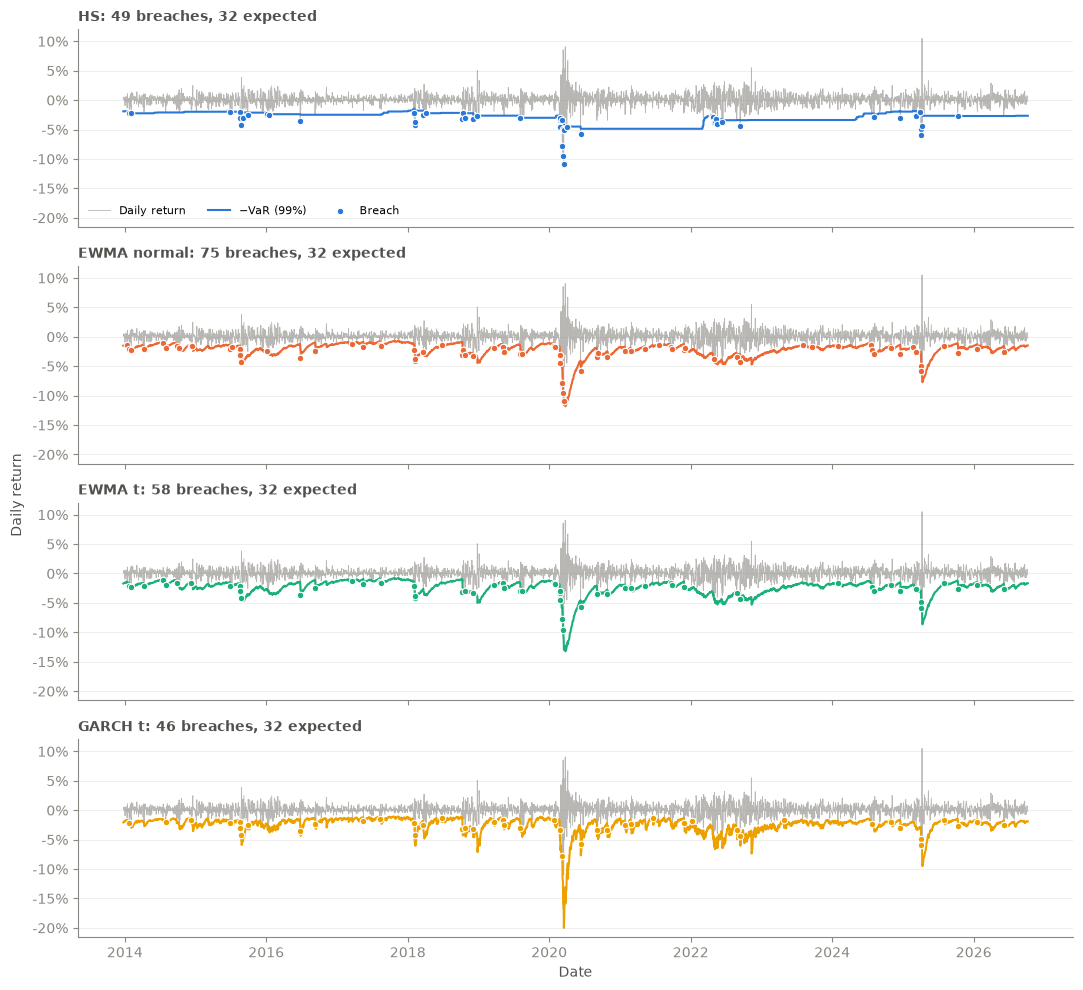

In [5]:
# reference palette, categorical slots 1-4
COLORS = {"HS": "#2a78d6", "EWMA normal": "#eb6834", "EWMA t": "#1baf7a", "GARCH t": "#eda100"}
MUTED, INK = "#898781", "#52514e"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
})

fig, axes = plt.subplots(len(COLORS), 1, figsize=(11, 10), sharex=True, sharey=True)
for ax, (name, color) in zip(axes, COLORS.items()):
    h = hits[name]
    ax.plot(returns_bt.index, returns_bt, color=MUTED, lw=0.6, alpha=0.6, label="Daily return")
    ax.plot(var.index, -var[name], color=color, lw=1.5, label="−VaR (99%)")
    ax.scatter(
        returns_bt.index[h], returns_bt[h], s=22, color=color,
        edgecolor="white", linewidth=0.8, zorder=3, label="Breach",
    )
    ax.set_title(f"{name}: {int(h.sum())} breaches, {ALPHA * len(h):.0f} expected", fontsize=10)
    ax.grid(axis="y", color=MUTED, alpha=0.2, lw=0.5)
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")

axes[0].legend(loc="lower left", frameon=False, fontsize=8, ncols=3)
axes[-1].set_xlabel("Date")
fig.supylabel("Daily return", color=INK, fontsize=10)
fig.tight_layout()
plt.show()

## EWMA against GARCH volatility

Both models react to a shock within days. The difference is what happens afterwards: GARCH's variance reverts to a long-run level, while EWMA keeps falling for as long as markets stay calm. A visible jump every 21 days would mean the monthly refits are unstable.

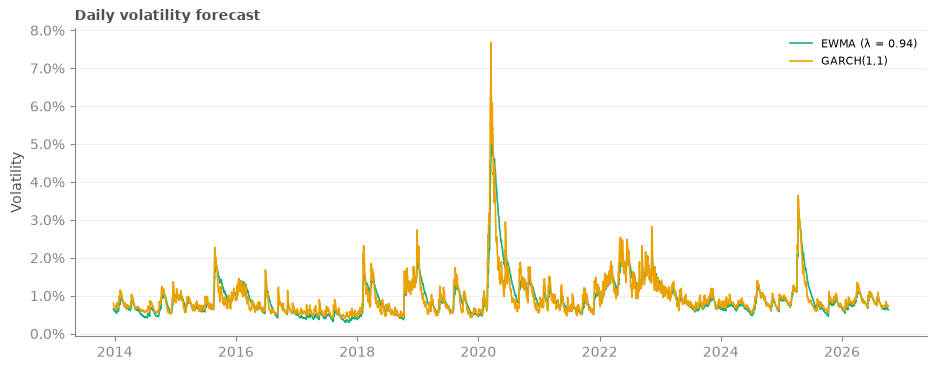

,EWMA,GARCH
mean,0.009331,0.009545
min,0.002963,0.004039
50%,0.007916,0.008104
max,0.050747,0.076803


In [6]:
vols = pd.DataFrame({"EWMA": sigma, "GARCH": sigma_garch}).loc[var.index]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(vols.index, vols["EWMA"], color=COLORS["EWMA t"], lw=1.2, label="EWMA (λ = 0.94)")
ax.plot(vols.index, vols["GARCH"], color=COLORS["GARCH t"], lw=1.2, label="GARCH(1,1)")
ax.set_title("Daily volatility forecast", fontsize=10)
ax.set_ylabel("Volatility")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.1%}")
ax.grid(axis="y", color=MUTED, alpha=0.2, lw=0.5)
ax.legend(frameon=False, fontsize=8)
plt.show()

vols.describe().loc[["mean", "min", "50%", "max"]]

## Breaches per year

The Kupiec test only counts breaches, so it can't see clustering. Counting them by year shows it: a good model's breaches are spread out, and a slow model's pile up in crisis years. The dashed line is the expected count per year (about 2.5 at 99%).

The Christoffersen test turns this into a formal check.

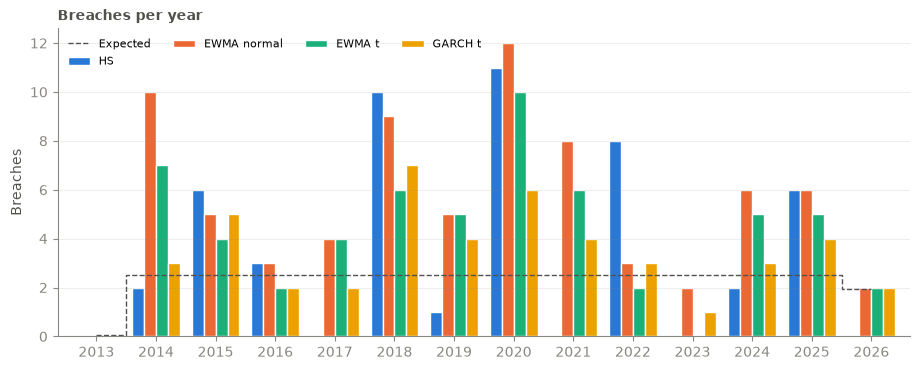

,HS,EWMA normal,EWMA t,GARCH t,days
Date,,,,,
2013,0,0,0,0,5
2014,2,10,7,3,252
2015,6,5,4,5,252
2016,3,3,2,2,252
2017,0,4,4,2,251
2018,10,9,6,7,251
2019,1,5,5,4,252
2020,11,12,10,6,253
2021,0,8,6,4,252


In [7]:
by_year = pd.DataFrame(hits).groupby(lambda d: d.year).sum()
days_per_year = pd.DataFrame(hits).groupby(lambda d: d.year).size()

ax = by_year.plot.bar(
    figsize=(11, 4), width=0.8, color=[COLORS[c] for c in by_year.columns],
    edgecolor="white", linewidth=1,
)
ax.step(
    range(len(days_per_year)), ALPHA * days_per_year, where="mid",
    color=INK, ls="--", lw=1, label="Expected",
)
ax.set_title("Breaches per year", fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("Breaches")
ax.grid(axis="y", color=MUTED, alpha=0.2, lw=0.5)
ax.legend(frameon=False, fontsize=8, ncols=4)
plt.xticks(rotation=0)
plt.show()

by_year.assign(days=days_per_year)

## Takeaways

These numbers are from SPY at 99%, 2013-12-24 to 2026-10-07 (3,215 days). Rerun to refresh them. GARCH's 1,000-day warm-up pushes the start of the window to late 2013, so every model is tested on fewer days than before, and the counts for the old models changed too.

- **GARCH t is the best of the four on every test, but still fails all three at 5%.** It has 46 breaches against 32.2 expected (1.43%), so Kupiec rejects it (p = 0.021), and breaches still cluster (Christoffersen p = 0.004). Conditional coverage rejects it at p = 0.001.
- **Mean reversion fixes most of EWMA's calm-market problem.** GARCH's volatility has a floor: its lowest forecast is 0.40% a day, against 0.30% for EWMA. That shows up in calm years: 3 breaches in 2014 against 7-10 for EWMA, and 4 in 2021 against 6-8.
- **GARCH reacts harder to crashes.** Its 2020 volatility peaks at 7.7% a day against 5.1% for EWMA, and it has 6 breaches that year against 10-12 for the others.
- **Clustering is no better than EWMA t.** Christoffersen p is 0.004 for both. Getting the volatility level right isn't enough when the second and third days of a sell-off still breach.
- **HS now fails Kupiec too.** 49 breaches against 32.2 expected (p = 0.006). It passed on the longer 2011 window only because 2012-2013 had no breaches, so that pass was down to the window, not the model.
- **What to try:** GJR-GARCH, where falls raise volatility more than rises do (the leverage effect), letting ν come from each fit instead of fixing it at 5, or filtered historical simulation, which scales historical returns by GARCH volatility instead of assuming a t tail.